# Assignment 5, Question 4: Data Exploration

**Points: 15**

In this notebook, you'll explore the clinical trial dataset using pandas selection and filtering techniques.

You'll use utility functions from `q3_data_utils` where helpful, but also demonstrate direct pandas operations.

## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Import utilities from Q3
from q3_data_utils import load_data, detect_missing, filter_data

# Load the data
df = load_data('output/clinical_trial_cleaned.csv')
print(f"Loaded {len(df)} patients with {len(df.columns)} variables")

# Prewritten visualization functions for exploration
def plot_value_counts(series, title, figsize=(10, 6)):
    """
    Create a bar chart of value counts.
    
    Args:
        series: pandas Series with value counts
        title: Chart title
        figsize: Figure size tuple
    """
    plt.figure(figsize=figsize)
    series.plot(kind='bar')
    plt.title(title)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

def plot_crosstab(crosstab_data, title, figsize=(10, 6)):
    """
    Create a heatmap of crosstab data.
    
    Args:
        crosstab_data: pandas DataFrame from pd.crosstab()
        title: Chart title
        figsize: Figure size tuple
    """
    plt.figure(figsize=figsize)
    plt.imshow(crosstab_data.values, cmap='Blues', aspect='auto')
    plt.colorbar()
    plt.title(title)
    plt.xticks(range(len(crosstab_data.columns)), crosstab_data.columns, rotation=45)
    plt.yticks(range(len(crosstab_data.index)), crosstab_data.index)
    plt.tight_layout()
    plt.show()

Loaded 10000 patients with 18 variables


## Part 1: Basic Exploration (3 points)

Display:
1. Dataset shape
2. Column names and types
3. First 10 rows
4. Summary statistics (.describe())

In [2]:
# TODO: Display dataset info

print("\nDataset Info:", df.shape)
print("Columns:", df.columns.tolist())
print("Data Types:\n", df.dtypes)
print("First 10 rows", df.head(10))




Dataset Info: (10000, 18)
Columns: ['patient_id', 'age', 'sex', 'bmi', 'enrollment_date', 'systolic_bp', 'diastolic_bp', 'cholesterol_total', 'cholesterol_hdl', 'cholesterol_ldl', 'glucose_fasting', 'site', 'intervention_group', 'follow_up_months', 'adverse_events', 'outcome_cvd', 'adherence_pct', 'dropout']
Data Types:
 patient_id             object
age                   float64
sex                    object
bmi                   float64
enrollment_date        object
systolic_bp           float64
diastolic_bp          float64
cholesterol_total     float64
cholesterol_hdl       float64
cholesterol_ldl       float64
glucose_fasting       float64
site                   object
intervention_group     object
follow_up_months        int64
adverse_events          int64
outcome_cvd            object
adherence_pct         float64
dropout                object
dtype: object
First 10 rows   patient_id   age         sex   bmi enrollment_date  systolic_bp  \
0     P00001  80.0           F  29.0   

## Part 2: Column Selection (3 points)

Demonstrate different selection methods:

1. Select only numeric columns using `.select_dtypes()`
2. Select specific columns by name
3. Select a subset of rows and columns using `.loc[]`

In [3]:
# TODO: Select numeric columns
print("\nSelecting numeric columns...\n", df.select_dtypes(include=[np.number]).columns.tolist())


Selecting numeric columns...
 ['age', 'bmi', 'systolic_bp', 'diastolic_bp', 'cholesterol_total', 'cholesterol_hdl', 'cholesterol_ldl', 'glucose_fasting', 'follow_up_months', 'adverse_events', 'adherence_pct']


In [4]:
# TODO: Select specific columns
print("\nSelecting specific columns 'age', 'bmi', 'systolic_bp'...\n", df[['age', 'bmi', 'systolic_bp']].head())


Selecting specific columns 'age', 'bmi', 'systolic_bp'...
     age   bmi  systolic_bp
0  80.0  29.0        123.0
1  80.0  26.0        139.0
2  82.0  26.0        123.0
3  95.0  25.0        116.0
4  95.0  26.0         97.0


In [5]:
# TODO: Use .loc[] to select subset
print("\nUsing .loc[] to select subset...\n", df.loc[0:5, ['age', 'bmi', 'systolic_bp']])


Using .loc[] to select subset...
     age   bmi  systolic_bp
0  80.0  29.0        123.0
1  80.0  26.0        139.0
2  82.0  26.0        123.0
3  95.0  25.0        116.0
4  95.0  26.0         97.0
5  78.0  27.0        116.0


## Part 3: Filtering (4 points)

Filter the data to answer these questions:

1. How many patients are over 65 years old?
2. How many patients have systolic BP > 140?
3. Find patients who are both over 65 AND have systolic BP > 140
4. Find patients from Site A or Site B using `.isin()`

In [6]:
# TODO: Filter and count patients over 65

df_over_65 = filter_data(df, filters =[{'column': 'age', 'condition': 'greater', 'value': 65}])
print(f"\nPatients over 65: {len(df_over_65)}")



Patients over 65: 8526


In [7]:
# TODO: Filter for high BP
df_sbp_140 = filter_data(df, filters =[{'column': 'systolic_bp', 'condition': 'greater', 'value': 140}])
print(f"\nPatients with high BP: {len(df_sbp_140)}")



Patients with high BP: 538


In [8]:
# TODO: Multiple conditions with &
df_65_sbp_140 = df[(df["age"] > 65) & (df["systolic_bp"] > 140)]
print(f"\nPatients over 65 with high BP: {len(df_65_sbp_140)}")



Patients over 65 with high BP: 476


In [9]:
# TODO: Filter by site using .isin()
df_65_sbp_140[df["site"].isin(["Site A", "Site B"])]


/tmp/ipykernel_295743/1486270168.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_65_sbp_140[df["site"].isin(["Site A", "Site B"])]


,patient_id,age,sex,bmi,enrollment_date,systolic_bp,diastolic_bp,cholesterol_total,cholesterol_hdl,cholesterol_ldl,glucose_fasting,site,intervention_group,follow_up_months,adverse_events,outcome_cvd,adherence_pct,dropout
33,P00034,83.0,Male,37.0,2022-01-18,143.0,100.0,187.0,51.0,99.0,115.0,Site B,Control,24,0,Yes,61.0,Yes
121,P00122,95.0,Female,36.0,16-11-2022,144.0,86.0,241.0,65.0,128.0,127.0,Site B,Treatment B,14,0,No,52.0,No
124,P00125,95.0,Female,28.0,2022-06-18,147.0,118.0,183.0,49.0,97.0,86.0,Site B,Treatment B,19,1,No,100.0,No
223,P00224,97.0,Female,22.0,2023-09-01,141.0,88.0,157.0,60.0,66.0,115.0,Site B,Control,4,0,Yes,55.0,No
273,P00274,81.0,Female,29.0,06-08-2022,142.0,87.0,145.0,80.0,40.0,80.0,Site A,Treatment B,17,0,yes,60.0,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9676,P09677,68.0,Female,27.0,2022-03-12,141.0,83.0,158.0,60.0,66.0,66.0,Site B,Treatment B,22,0,No,61.0,Yes
9728,P09729,83.0,M,26.0,2022-02-07,141.0,87.0,214.0,58.0,113.0,107.0,Site A,Control,23,0,Yes,61.0,Yes
9862,P09863,89.0,F,30.0,2022-10-02,150.0,82.0,182.0,55.0,91.0,118.0,Site B,Control,15,0,No,39.0,No
9864,P09865,72.0,M,27.0,2022-07-04,146.0,83.0,182.0,49.0,97.0,95.0,Site A,Treatment B,18,0,Yes,72.0,No


## Part 4: Value Counts and Grouping (5 points)

1. Get value counts for the 'site' column
2. Get value counts for the 'intervention_group' column  
3. Create a crosstab of site vs intervention_group
4. Calculate mean age by site
5. Save the site value counts to `output/q4_site_counts.csv`

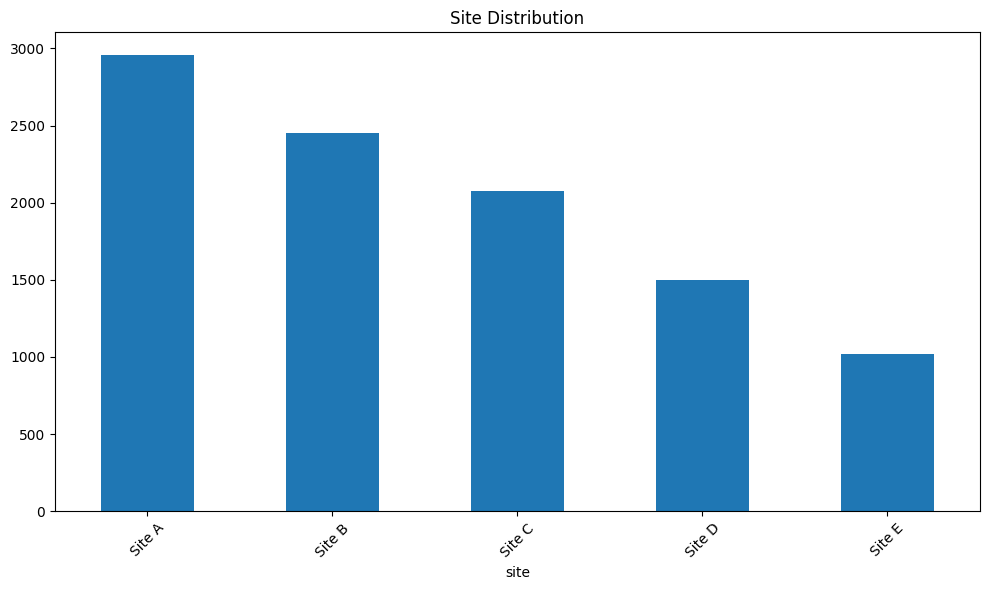

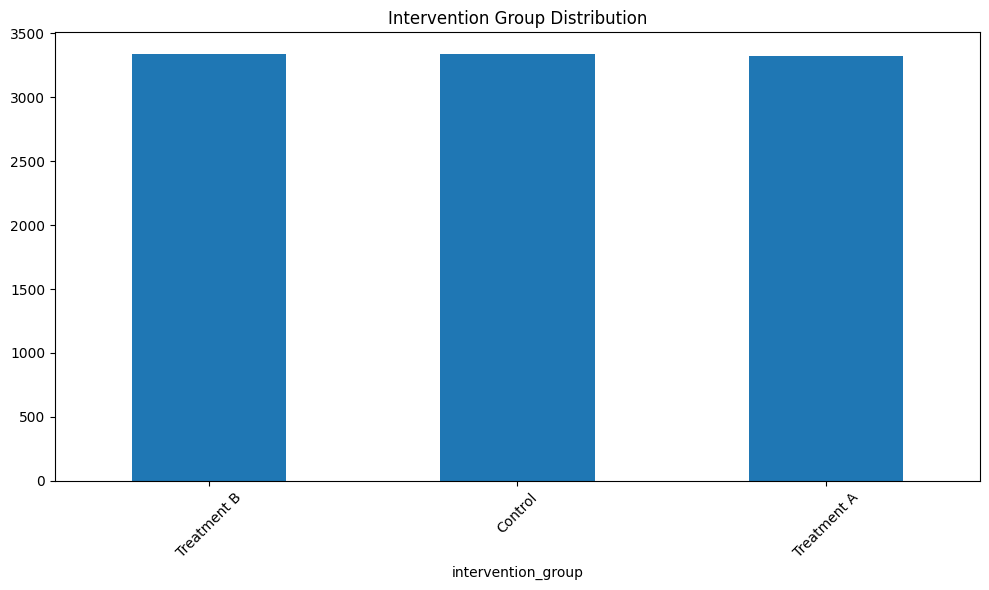

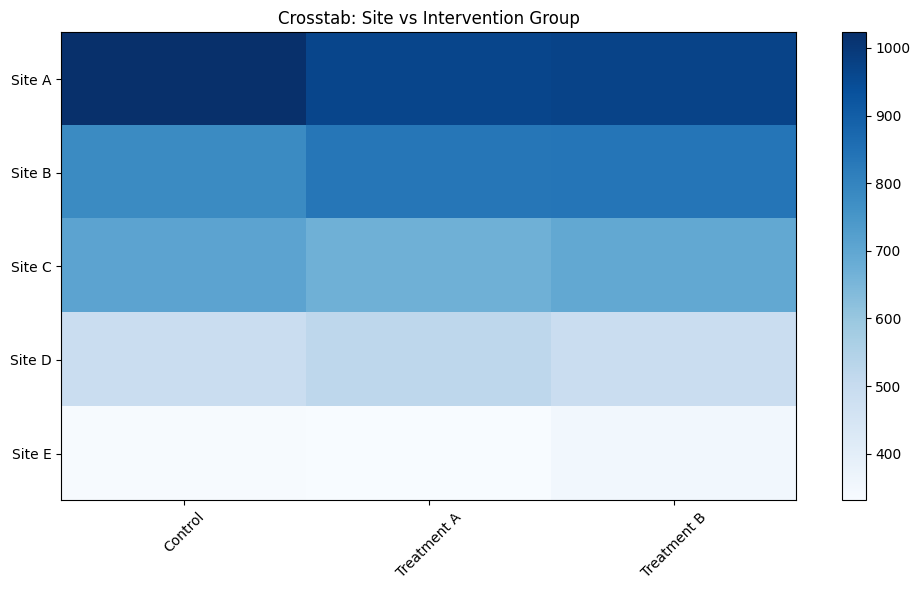


Mean age by site:
 site
Site A    81.208390
Site B    80.453322
Site C    80.756392
Site D    80.759494
Site E    80.427729
Name: age, dtype: float64


In [10]:
# TODO: Value counts and analysis

#Clean-up Site names, then plot value counts
df["site"] = (
        df["site"]
        .str.strip()          
        .str.replace("_", " ")  
        .str.replace(r"\s+", " ", regex=True)
        .str.title()           
    )
plot_value_counts(df['site'].value_counts(), "Site Distribution")

#Clean-up intervention group column, then plot value counts
df["intervention_group"] = (
        df["intervention_group"]
        .str.strip()          
        .str.replace("_", " ")  
        .str.replace(r"\s+", " ", regex=True)
        .str.title()
        .str.replace("Treatmenta", "Treatment A")
        .str.replace("Treatmen A", "Treatment A")  
        .str.replace("Contrl", "Control")         
    )
plot_value_counts(df['intervention_group'].value_counts(), "Intervention Group Distribution")

#Crosstab of site vs intervention group
crosstab_site_intervention = pd.crosstab(df['site'], df['intervention_group'])
plot_crosstab(crosstab_site_intervention, "Crosstab: Site vs Intervention Group")

#Mean age by site
mean_age_by_site = df.groupby('site')['age'].mean()
print("\nMean age by site:\n", mean_age_by_site)



In [11]:
# TODO: Save output

site_counts = df['site'].value_counts()
site_counts.to_csv('output/q4_site_counts.csv')


## Summary

Write 2-3 sentences about what you learned from exploring this dataset.

**Your summary here:**

TODO: Write your observations

This dataset appears to have three intervention groups (Treatment A and B and Control), as well as five sites that the study was conducted at (Sites A-E). I also learned that though there are around 8300 patients over 65 years of age, there seems to be a smaller number of people with high BP (systolic >140) which is surprising to me. I think I can learn a lot more from this dataset as well!
